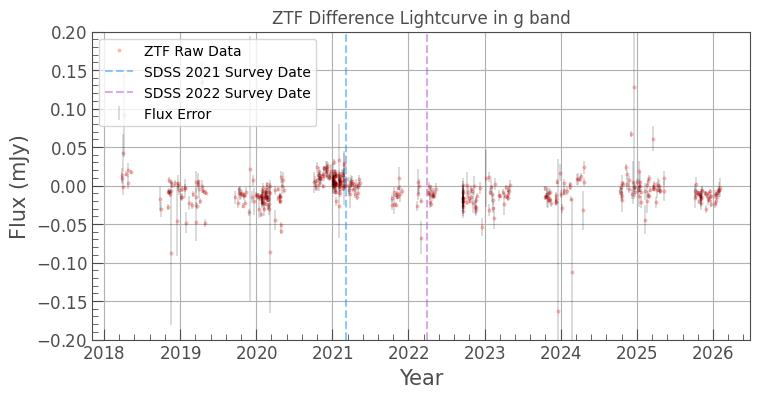

In [8]:
import numpy as np
from astropy.table import Table
import sys
import os
import re
import astropy.io.fits as fits
import argparse as ap
from astropy.time import Time
from astropy.coordinates import (SkyCoord, EarthLocation)
import astropy.units as u
from astropy.stats import sigma_clip
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import lightkurve as lk
import juliandate as jd
from scipy.stats import sem
from astroquery.ipac.irsa import Irsa
from IPython.display import display
from IPython.core.interactiveshell import InteractiveShell

# Your list of column names
keys = [
    'index', 'field', 'ccdid', 'qid', 'filter', 'pid', 'infobitssci', 'sciinpseeing', 
    'scibckgnd', 'scisigpix', 'zpmaginpsci', 'zpmaginpsciunc', 'zpmaginpscirms', 
    'clrcoeff', 'clrcoeffunc', 'ncalmatches', 'exptime', 'adpctdif1', 'adpctdif2', 
    'diffmaglim', 'zpdiff', 'programid', 'jd', 'rfid', 'diffimgstatus', 
    'forcediffimflux', 'forcediffimfluxunc', 'forcediffimsnr', 'forcediffimchisq', 
    'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap', 'aperturecorr', 
    'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc', 'nearestrefchi', 
    'nearestrefsharp', 'refjdstart', 'refjdend', 'procstatus'
]

file_path = '/Users/shaunparasher/Documents/VS Code/denison_2026_test/shaun/Data/ZTF Data/ztf.txt'

ztf_phot = pd.read_csv(file_path, sep='\s+', names=keys, header=None, comment='#')

ztf_g = ztf_phot[ztf_phot['filter'] == 'ZTF_g']
ztf_r = ztf_phot[ztf_phot['filter'] == 'ZTF_r']
ztf_i = ztf_phot[ztf_phot['filter'] == 'ZTF_i']

subset = ztf_g #change this depending on what you want
band = 'g'

counts_to_mJy = 3631 * 1000 * 10**(-0.4 * subset['zpmaginpsci'])
flux = subset['forcediffimflux'] * counts_to_mJy
flux_err = subset['forcediffimfluxunc'] * counts_to_mJy

t_years = Time(subset['jd'], format='jd').decimalyear
curve = lk.LightCurve(time=t_years, flux=flux, flux_err=flux_err)
ax = curve.plot(alpha=0.2, color='red', label='ZTF Raw Data', linestyle='none', marker='o')
curve.errorbar(ax=ax, color='black', label='Flux Error', fmt='o', markersize=0, lw=0.2)
ax.set_xlabel("Year")
ax.set_ylabel("Flux (mJy)")
ax.set_title(f"ZTF Difference Lightcurve in {band} band")
plt.axvline(x=2021.186, label='SDSS 2021 Survey Date', color = 'dodgerblue', linestyle='dashed', alpha = 0.5)
plt.axvline(x=2022.238888888889, label='SDSS 2022 Survey Date', color = 'mediumorchid', linestyle='dashed', alpha = 0.5)
plt.legend(loc='upper left')
plt.grid()
plt.ylim(-0.2, 0.2)
plt.show()